## Assignment 7: Well-log Missing Prediction with Recurrent Networks


In [1]:
from pathlib import Path
from IPython.display import Markdown, display
import matplotlib.pyplot as plt

from assignment7 import (
    get_runtime_summary,
    rows_to_markdown,
    summarize_assignment_rationale,
    run_assignment_workflow,
    summarize_best_model,
)

DATA_PATH = Path('well4tutorial2.xlsx')
SEQUENCE_LENGTHS = [8, 16]

SEARCH_SPACE = {
    'base_hidden_size': [8, 16],
    'num_layers': [2, 4],
    'learning_rate': [1e-3, 5e-4],
    'batch_size': [128],
    'weight_decay': [0.0],
}

RUN_CONFIG = {
    'tune_train_limit': 12000,
    'tune_val_limit': 3000,
    'tune_epochs': 10,
    'tune_patience': 3,
    'final_epochs': 18,
    'final_patience': 4,
    'device': 'cuda',
    'seed': 42,
}

runtime_summary = get_runtime_summary(RUN_CONFIG['device'])

runtime_summary, DATA_PATH, SEQUENCE_LENGTHS, SEARCH_SPACE, RUN_CONFIG


({'device': 'cuda',
  'cuda_available': True,
  'cuda_device_count': 1,
  'gpu_name': 'NVIDIA RTX 3500 Ada Generation Laptop GPU'},
 WindowsPath('well4tutorial2.xlsx'),
 [8, 16],
 {'base_hidden_size': [8, 16],
  'num_layers': [2, 4],
  'learning_rate': [0.001, 0.0005],
  'batch_size': [128],
  'weight_decay': [0.0]},
 {'tune_train_limit': 12000,
  'tune_val_limit': 3000,
  'tune_epochs': 10,
  'tune_patience': 3,
  'final_epochs': 18,
  'final_patience': 4,
  'device': 'cuda',
  'seed': 42})

In [2]:
display(Markdown('### Runtime Summary'))
display(Markdown(rows_to_markdown(
    [runtime_summary],
    columns=['device', 'cuda_available', 'cuda_device_count', 'gpu_name'],
)))

experiment_results = {}
for sequence_length in SEQUENCE_LENGTHS:
    display(Markdown(f'### Running experiments for sequence length = {sequence_length}'))
    experiment_results[sequence_length] = run_assignment_workflow(
        workbook_path=DATA_PATH,
        search_space=SEARCH_SPACE,
        sequence_length=sequence_length,
        **RUN_CONFIG,
    )

sorted(experiment_results.keys())


### Runtime Summary

| device | cuda_available | cuda_device_count | gpu_name |
| --- | --- | --- | --- |
| cuda | True | 1 | NVIDIA RTX 3500 Ada Generation Laptop GPU |

### Running experiments for sequence length = 8

### Running experiments for sequence length = 16

[8, 16]

In [3]:
for sequence_length, experiment_result in experiment_results.items():
    display(Markdown(f'## Sequence Length = {sequence_length}'))
    dataset_rows = [experiment_result['dataset_summary']]
    display(Markdown('### Dataset Summary'))
    display(Markdown(rows_to_markdown(
        dataset_rows,
        columns=['num_sequences', 'sequence_length', 'num_features', 'train_sequences', 'val_sequences', 'test_sequences', 'device', 'gpu_name'],
    )))

    for family_name, search_result in experiment_result['search_results'].items():
        ranked_rows = sorted(search_result['search_records'], key=lambda row: row['val_rmse'])
        display(Markdown(f'### Hyperparameter Search: {family_name}'))
        display(Markdown(rows_to_markdown(
            ranked_rows,
            columns=['sequence_length', 'base_hidden_size', 'num_layers', 'learning_rate', 'batch_size', 'val_rmse', 'val_r2'],
        )))


## Sequence Length = 8

### Dataset Summary

| num_sequences | sequence_length | num_features | train_sequences | val_sequences | test_sequences | device | gpu_name |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 50000 | 8 | 4 | 40000 | 5000 | 5000 | cuda | NVIDIA RTX 3500 Ada Generation Laptop GPU |

### Hyperparameter Search: RNN

| sequence_length | base_hidden_size | num_layers | learning_rate | batch_size | val_rmse | val_r2 |
| --- | --- | --- | --- | --- | --- | --- |
| 8 | 16 | 2 | 0.0010 | 128 | 17.7339 | 0.7715 |
| 8 | 8 | 2 | 0.0010 | 128 | 18.0215 | 0.7640 |
| 8 | 8 | 4 | 0.0010 | 128 | 18.3417 | 0.7555 |
| 8 | 16 | 4 | 0.0010 | 128 | 18.9539 | 0.7389 |
| 8 | 16 | 4 | 0.0005 | 128 | 19.0444 | 0.7364 |
| 8 | 16 | 2 | 0.0005 | 128 | 19.1543 | 0.7334 |
| 8 | 8 | 4 | 0.0005 | 128 | 20.0557 | 0.7077 |
| 8 | 8 | 2 | 0.0005 | 128 | 20.7001 | 0.6886 |

...

| sequence_length | base_hidden_size | num_layers | learning_rate | batch_size | val_rmse | val_r2 |
| --- | --- | --- | --- | --- | --- | --- |
| 16 | 16 | 2 | 0.0010 | 128 | 12.6448 | 0.8769 |
| 16 | 16 | 4 | 0.0010 | 128 | 13.0842 | 0.8682 |
| 16 | 8 | 2 | 0.0010 | 128 | 13.8278 | 0.8528 |
| 16 | 16 | 4 | 0.0005 | 128 | 15.0129 | 0.8265 |
| 16 | 16 | 2 | 0.0005 | 128 | 15.2946 | 0.8199 |
| 16 | 8 | 4 | 0.0010 | 128 | 15.3380 | 0.8189 |
| 16 | 8 | 2 | 0.0005 | 128 | 15.9554 | 0.8040 |
| 16 | 8 | 4 | 0.0005 | 128 | 17.6049 | 0.7614 |

### Hyperparameter Search: GRU

| sequence_length | base_hidden_size | num_layers | learning_rate | batch_size | val_rmse | val_r2 |
| --- | --- | --- | --- | --- | --- | --- |
| 16 | 16 | 4 | 0.0010 | 128 | 11.1881 | 0.9036 |
| 16 | 16 | 2 | 0.0010 | 128 | 12.1631 | 0.8861 |
| 16 | 8 | 4 | 0.0010 | 128 | 12.8514 | 0.8728 |
| 16 | 8 | 2 | 0.0010 | 128 | 13.3342 | 0.8631 |
| 16 | 16 | 2 | 0.0005 | 128 | 13.3738 | 0.8623 |
| 16 | 16 | 4 | 0.0005 | 128 | 14.1040 | 0.8468 |
| 16 | 8 | 2 | 0.0005 | 128 | 15.2255 | 0.8215 |
| 16 | 8 | 4 | 0.0005 | 128 | 15.9998 | 0.8029 |

### Hyperparameter Search: LSTM

| sequence_length | base_hidden_size | num_layers | learning_rate | batch_size | val_rmse | val_r2 |
| --- | --- | --- | --- | --- | --- | --- |
| 16 | 16 | 2 | 0.0010 | 128 | 11.2006 | 0.9034 |
| 16 | 8 | 2 | 0.0010 | 128 | 14.5224 | 0.8376 |
| 16 | 16 | 4 | 0.0010 | 128 | 14.6011 | 0.8359 |
| 16 | 8 | 4 | 0.0010 | 128 | 15.5483 | 0.8139 |
| 16 | 16 | 4 | 0.0005 | 128 | 15.6360 | 0.8118 |
| 16 | 16 | 2 | 0.0005 | 128 | 16.0279 | 0.8022 |
| 16 | 8 | 2 | 0.0005 | 128 | 16.7419 | 0.7842 |
| 16 | 8 | 4 | 0.0005 | 128 | 17.5730 | 0.7622 |

In [4]:
comparison_rows = []
best_rows_by_sequence = []

for sequence_length, experiment_result in experiment_results.items():
    sequence_rows = sorted(experiment_result['comparison_rows'], key=lambda row: row['rmse'])
    comparison_rows.extend(sequence_rows)
    best_rows_by_sequence.append(sequence_rows[0])

comparison_rows = sorted(comparison_rows, key=lambda row: row['rmse'])
best_rows_by_sequence = sorted(best_rows_by_sequence, key=lambda row: row['sequence_length'])

display(Markdown('### Best Model at Each Sequence Length'))
display(Markdown(rows_to_markdown(
    best_rows_by_sequence,
    columns=['sequence_length', 'model', 'rmse', 'r2', 'base_hidden_size', 'num_layers', 'learning_rate', 'batch_size'],
)))

display(Markdown('### Final Test-set Comparison Across All Models and Sequence Lengths'))
display(Markdown(rows_to_markdown(
    comparison_rows,
    columns=['sequence_length', 'model', 'rmse', 'r2', 'base_hidden_size', 'num_layers', 'learning_rate', 'batch_size'],
)))

display(Markdown('### Best Model Summary'))
display(Markdown(summarize_best_model(comparison_rows)))

display(Markdown(summarize_assignment_rationale(comparison_rows, best_rows_by_sequence)))


### Best Model at Each Sequence Length

| sequence_length | model | rmse | r2 | base_hidden_size | num_layers | learning_rate | batch_size |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 8 | BiLSTM | 10.1331 | 0.9161 | 16 | 2 | 0.0010 | 128 |
| 16 | BiLSTM | 6.3133 | 0.9684 | 16 | 2 | 0.0010 | 128 |

### Final Test-set Comparison Across All Models and Sequence Lengths

| sequence_length | model | rmse | r2 | base_hidden_size | num_layers | learning_rate | batch_size |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 16 | BiLSTM | 6.3133 | 0.9684 | 16 | 2 | 0.0010 | 128 |
| 16 | GRU | 6.6457 | 0.9650 | 16 | 4 | 0.0010 | 128 |
| 16 | LSTM | 6.7129 | 0.9643 | 16 | 2 | 0.0010 | 128 |
| 16 | BiGRU | 7.1265 | 0.9598 | 16 | 4 | 0.0010 | 128 |
| 16 | BiRNN | 8.0919 | 0.9481 | 16 | 2 | 0.0010 | 128 |
| 16 | RNN | 9.3922 | 0.9301 | 16 | 2 | 0.0010 | 128 |
| 8 | BiLSTM | 10.1331 | 0.9161 | 16 | 2 | 0.0010 | 128 |
| 8 | LSTM | 10.6406 | 0.9075 | 16 | 2 | 0.0010 | 128 |
| 8 | GRU | 11.2701 | 0.8962 | 16 | 4 | 0.0010 | 128 |
| 8 | BiRNN | 11.9695 | 0.8830 | 16 | 2 | 0.0010 | 128 |
| 8 | RNN | 12.1102 | 0.8802 | 16 | 2 | 0.0010 | 128 |
| 8 | BiGRU | 12.3207 | 0.8760 | 16 | 4 | 0.0010 | 128 |

### Best Model Summary

The best model is BiLSTM with RMSE=6.3133 and R2=0.9684 at sequence_length=16. It used base_hidden_size=16, num_layers=2, learning_rate=0.001, and batch_size=128.

### Final Discussion and Rationale
- The selected best model is `BiLSTM` at sequence length `16` because it achieved the lowest test RMSE (6.3133) while also keeping a strong R2 score (0.9684).
- The gap to the second-best model is `0.3324` RMSE, so the final choice is based on a direct performance advantage rather than only model complexity.
- The strongest bidirectional variant is `BiLSTM` with RMSE=6.3133 and R2=0.9684, which helps show whether using bidirectional recurrent layers improves prediction quality on this dataset.
- Comparing sequence lengths shows the best result at each setting: `seq=8`: `BiLSTM` (RMSE=10.1331, R2=0.9161); `seq=16`: `BiLSTM` (RMSE=6.3133, R2=0.9684).
- Based on the sequence-length comparison, sequence length `16` is preferred because its best model produced the lowest RMSE among the tested sequence settings.
- This gives a practical rationale for model selection: prioritize the configuration with the lowest RMSE, verify that its R2 remains competitive, and then use the sequence-length comparison to justify whether a longer temporal context helps.

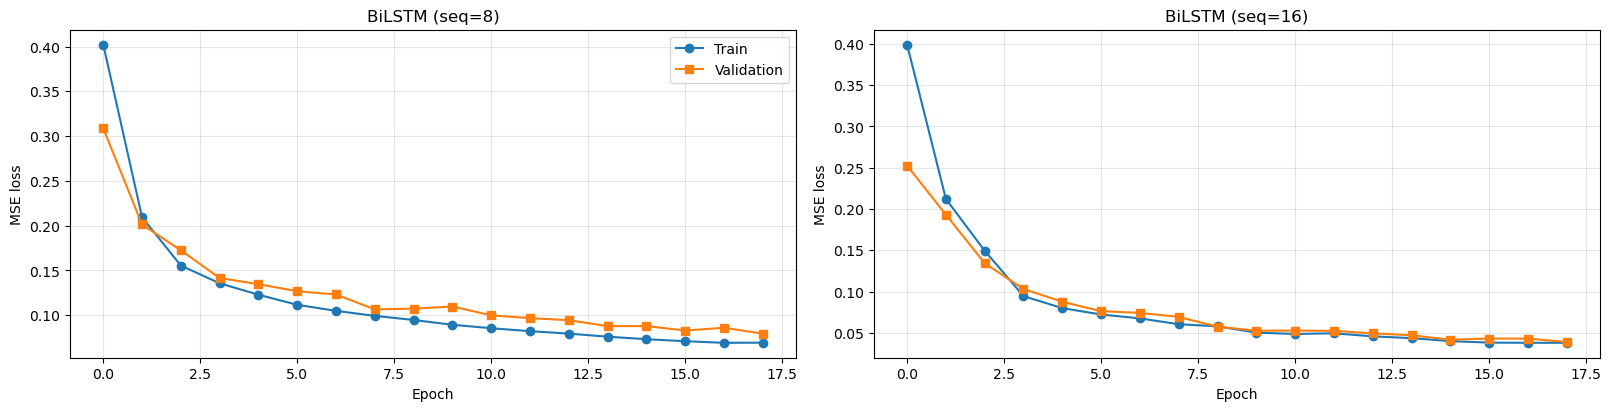

In [5]:
fig, axes = plt.subplots(1, len(best_rows_by_sequence), figsize=(8 * len(best_rows_by_sequence), 4), constrained_layout=True)
if len(best_rows_by_sequence) == 1:
    axes = [axes]

for ax, best_row in zip(axes, best_rows_by_sequence):
    sequence_length = best_row['sequence_length']
    model_name = best_row['model']
    best_run = experiment_results[sequence_length]['runs'][model_name]
    history = best_run['history']
    ax.plot(history['train_loss'], marker='o', label='Train')
    ax.plot(history['val_loss'], marker='s', label='Validation')
    ax.set_title(f'{model_name} (seq={sequence_length})')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE loss')
    ax.grid(alpha=0.3)

axes[0].legend()
plt.show()


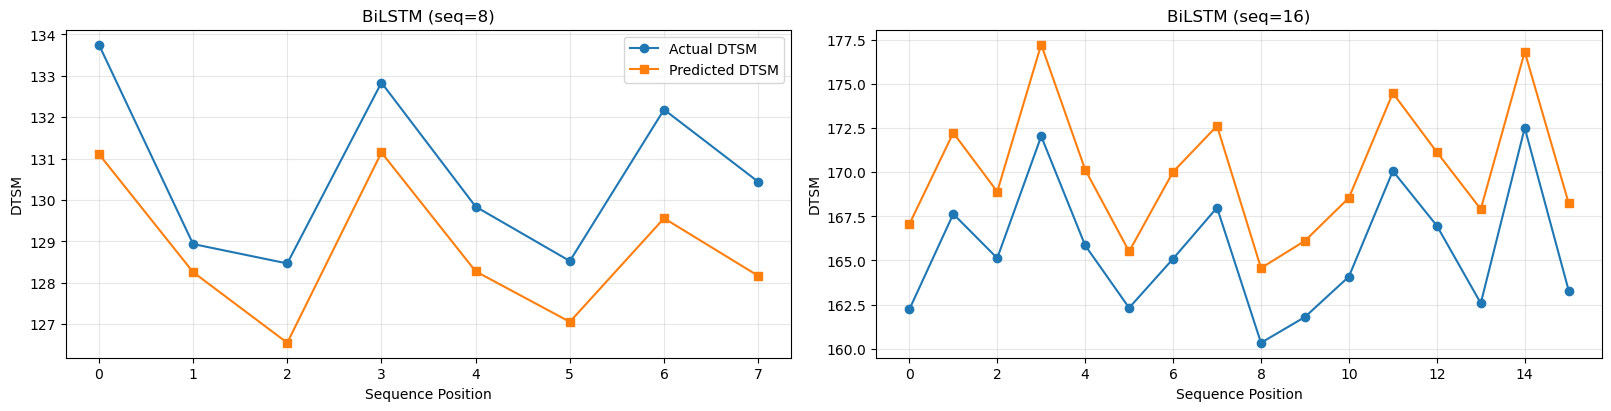

In [6]:
fig, axes = plt.subplots(1, len(best_rows_by_sequence), figsize=(8 * len(best_rows_by_sequence), 4), constrained_layout=True)
if len(best_rows_by_sequence) == 1:
    axes = [axes]

sample_index = 0
for ax, best_row in zip(axes, best_rows_by_sequence):
    sequence_length = best_row['sequence_length']
    model_name = best_row['model']
    best_run = experiment_results[sequence_length]['runs'][model_name]
    ax.plot(best_run['targets']['test'][sample_index], marker='o', label='Actual DTSM')
    ax.plot(best_run['predictions']['test'][sample_index], marker='s', label='Predicted DTSM')
    ax.set_title(f'{model_name} (seq={sequence_length})')
    ax.set_xlabel('Sequence Position')
    ax.set_ylabel('DTSM')
    ax.grid(alpha=0.3)

axes[0].legend()
plt.show()
